In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
# removing scientific notation
pd.options.display.float_format = '{:.2f}'.format

Begin by importing the necessary libraries and changin the display to  scientific notation.

In [ ]:
qsales = pd.read_csv('qSales_2024 (3).csv')
qsales['datadate'] = pd.to_datetime(qsales['datadate'])
target_sales = qsales.loc[qsales['tic']=='TGT']

next we want to create a new varaible for the dataset and read it, and make sure that in this, the variable datadate is a date

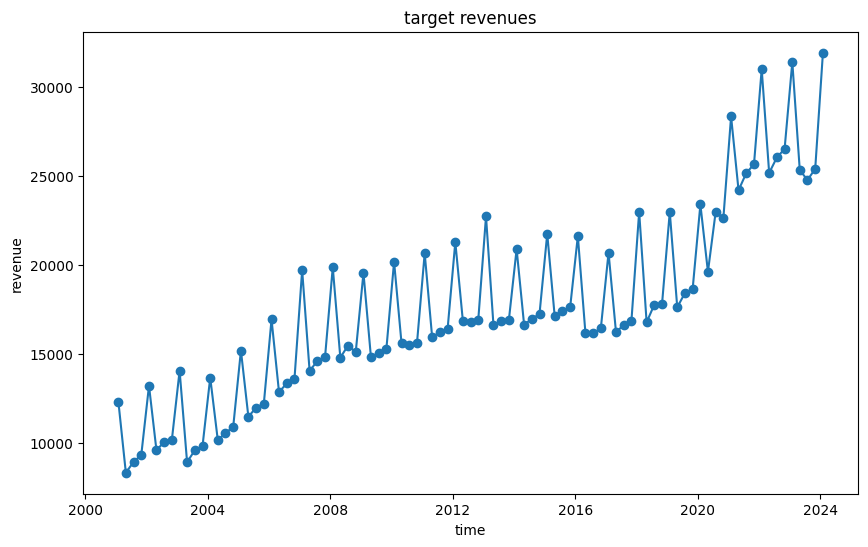

In [ ]:
plt.figure(figsize=(10,6))

plt.title('target revenues')

plt.xlabel('time')
plt.ylabel('revenue')

plt.plot(target_sales['datadate'],target_sales['saleq'], marker='o')

Next we want to visualize the data to identify underlying trends. The time series reveals a recurring spike in revenue during the fourth quarter (Q4) of each year, reflecting the expected increase in holiday sales. Additionally, there is a upward shift in revenue beginning in 2021 following the COVID-19 pandemic. To account for these seasonal and post-pandemic effects, two dummy variables are created one for holiday and another for covid.

In [ ]:
target_sales['time'] = range(1, len(target_sales) + 1)

target_sales['holiday'] = np.where(target_sales['fqtr']==4,1,0)
target_sales['holiday_it'] = target_sales['time'] * target_sales['holiday']

target_sales['covid'] = np.where(target_sales['datadate']>'2020', 1, 0)
target_sales['covid_it'] = target_sales['time']*target_sales['covid']

dt4training = target_sales[:int(0.75 * len(target_sales))]
dt4testing = target_sales[int(0.75 * len(target_sales)):]

/tmp/ipykernel_2177/2285362993.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['time'] = range(1, len(target_sales) + 1)
/tmp/ipykernel_2177/2285362993.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['holiday'] = np.where(target_sales['fqtr']==4,1,0)
/tmp/ipykernel_2177/2285362993.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

The first line of code creates a time variable, which allows us to track the progression of time across the dataset. This helps us visualize and capture the overall growth trend in Target’s revenue over the years.

The next step is creating a holiday dummy variable to capture the consistent increase in revenue during Q4, which is expected given the impact of the holiday shopping season on retail sales. We also create an interaction variable by multiplying the time variable with the holiday dummy to account for whether the effect of the holiday season changes over time.

A COVID dummy variable is then created to capture the noticeable increase in revenue beginning in 2021, reflecting the shift that occurred following the pandemic.

After creating these variables, the dataset is split into training and testing sets, using 75% of the data for model development and the remaining 25% to evaluate the model’s performance.

One important limitation to note is that the COVID dummy variable has little impact on the current model because the training data does not include any observations from 2021 onward. Since the model never sees the post-COVID period during training, it cannot properly estimate the effect of this variable. However, this variable could become valuable in a larger dataset that includes more recent years like up to 2026 for example, as it would allow the model to better capture changes in revenue patterns after COVID-19.

In [ ]:
x = dt4training.loc[:,['time', 'holiday','holiday_it','dummy_covidtime','covid_it']]
x = sm.add_constant(x)

y = dt4training.loc[:,'saleq']

model1 = sm.OLS(y,x).fit()

model1.params

,0
const,9470.64
time,134.90
holiday,4006.81
holiday_it,15.53
dummy_covidtime,0.00
covid_it,0.00


In [ ]:
x_test = dt4testing.loc[:,['time','holiday','holiday_it','covid','covid_it']]
x_test = sm.add_constant(x_test)

revenue = 9470.64 + 134 * time + (4006.81) * holiday + 15.53 * holiday_it

note: we can see that the dummy and interaction terms = 0 for the covid variable which matches out to the explaination above

In [ ]:
modeltest = dt4testing.copy()
modeltest['predict_revenue'] = model1.predict(x_test)
modeltest['APE'] = abs((modeltest['saleq']-modeltest['predict_revenue'])/modeltest['saleq'])
modeltest['APE'].mean()

np.float64(0.12011310829121091)

To test the model’s forecasting ability, we apply it to the testing dataset, which contains data the model has not seen before. The model generates predicted revenue values, which are then compared against the actual revenue values. We calculate the percentage error for each prediction and average these errors to obtain the MAPE. This allows us to measure how accurately the model can predict Target’s revenue on new data.

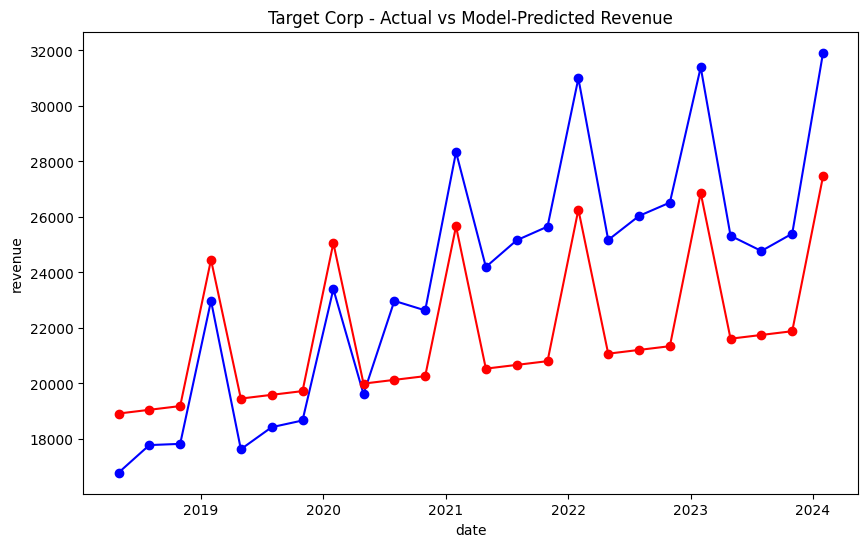

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Target Corp - Actual vs Model-Predicted Revenue')
plt.xlabel('date')
plt.ylabel('revenue')
plt.plot(modeltest['datadate'],modeltest['saleq'],marker='o',color='blue')
plt.plot(modeltest['datadate'],modeltest['predict_revenue'],marker='o',color='red')

# blue is actual
# red is predicted

The graph makes the model’s patterns and limitations more apparent. We can clearly see the recurring Q4 revenue spikes, which reflect the expected increase in holiday sales. However, the impact of the COVID dummy variable is not visible, which is consistent with the issue discussed earlier. Because the training data does not include any years after 2021, the model does not have enough information to identify the post-COVID revenue impact.

To: Chapman Wealth Management
From: Mayurri Ravirajan, Quantfolio Solutions
Re: Target Corporation - Quarterly Revenue Regression Analysis

Our model incorporates two dummy variables, Holiday and Covid, along with interaction terms allowing each effect to change over time, representing the two most significant patterns identified in Target's historical revenue data. Holiday equals 1 for Target's fiscal fourth quarter and 0 otherwise, capturing the increase in revenue driven by seasonal shopping, promotions, and gift-giving during the holiday period. Covid equals 1 for quarters occurring in 2021 or later and 0 otherwise, intended to capture the increase in revenue we observed visually following the onset of the pandemic. It is important to note, however, that because the model was trained on the first 75% of the data, which ends before 2021, the training set contains no quarters in which the Covid dummy is active. As a result, both the Covid coefficient and its interaction term were estimated at 0.00, meaning this variable had no measurable effect on the fitted model. This reflects a limitation of the training and testing split we used rather than a finding that COVID had no real impact on Target's revenue, since the increase in revenue from 2020 onward is clearly visible in the raw data.

With a MAPE of 12%, our model's predictions differ from actual revenue by about 12% on average over the testing period, which represents a reasonable but imperfect fit. The model captures Target's underlying growth trend and its holiday seasonality reasonably well, but loses some accuracy in the more recent quarters, where the un-modeled COVID-era increase has the largest impact on actual revenue. This error could likely be reduced with a larger dataset or a different training and testing split that retains enough post-2020 observations for the Covid dummy to take effect.


Chapman should consider how Target's revenue has historically increased year after year, with a consistent and predictable spike occurring during each holiday quarter, estimated at  4,006.81 above baseline, and growing modestly over time. Chapman should also be aware that revenue increases by only about $134.90 per piriod of time on the underlying trend, meaning that Target's organic growth, excluding seasonal and pandemic-related effects, is slow but stable. Finally, Chapman should recognize that the true effect of COVID-19 on Target's revenue could not be reliably estimated using this model, given that the training data excluded nearly all COVID-era quarters, and this should be treated as an open question for further analysis rather than evidence that the pandemic had no lasting effect on the business.
